# 03 · Shares por clase, D-CPI y comparación de salarios reales

Última pieza del POC. Tres pasos:
1. Para cada hogar de la ENGH con al menos un ocupado, asignar la clase del **ocupado de mayor ingreso** (proxy del 'jefe económico'). Calcular shares promedio por clase.
2. Cargar (o sintetizar, en este POC) un IPC trimestral por división. Construir el **D-CPI por clase** = Σ shares × IPC división.
3. Deflactar los salarios EPH por clase con (a) el IPC oficial y (b) el D-CPI propio. Comparar.

**Por qué el ocupado de mayor ingreso y no el jefe del hogar**: el jefe en ENGH puede ser inactivo (jubilado, ama de casa). Para que el matching tenga sentido, asignamos la clase de quien efectivamente está ocupado y aporta más al hogar. Es una decisión simplificadora documentable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

hog = pd.read_parquet("data/engh_hogares.parquet")
ocu = pd.read_parquet("data/engh_ocupados_with_lca.parquet")

CLASS_NAMES = {
    0: "Obreros formales (sec.)",
    1: "Asalariados informales jóvenes",
    2: "Trabajadores mayores con primario",
    3: "Profesionales asalariadas",
    4: "Cuentapropistas y patrones",
}

In [16]:
ocu.head()

,id,miembro,pondera,SEXO,EDAD_GRP,NIVEL_ED_3,CAT_OCUP,REGION,ingtotp,SEXO_enc,EDAD_GRP_enc,NIVEL_ED_3_enc,CAT_OCUP_enc,REGION_enc,LCA_class_pred,LCA_p0,LCA_p1,LCA_p2,LCA_p3,LCA_p4
0,635779227,1,283,Varon,<25,Superior,Obrero o empleado,Gran Buenos Aires,26633.333333,1,4,2,1,1,2,0.00000,0.0,0.502732,0.497268,0.0
1,995013,1,549,Varon,50-64,Hasta_primario,Obrero o empleado,Gran Buenos Aires,42000.000000,1,2,0,1,1,4,0.00000,0.0,0.000000,0.000000,1.0
2,995013,2,549,Mujer,35-49,Superior,Obrero o empleado,Gran Buenos Aires,15166.666667,0,1,2,1,1,2,0.00000,0.0,1.000000,0.000000,0.0
3,995013,3,549,Varon,<25,Secundario,Obrero o empleado,Gran Buenos Aires,6500.000000,1,4,1,1,1,3,0.43277,0.0,0.000000,0.567230,0.0
4,459317539,1,603,Mujer,65+,Superior,Cuenta Propia,Gran Buenos Aires,82666.666667,0,3,2,0,1,1,0.00000,1.0,0.000000,0.000000,0.0


In [18]:
hog.head()

,id,region,pondera,regten,jniveled,jsexo,jedad_agrup,jocupengh,cantmiem,menor14,...,share_03,share_04,share_05,share_06,share_07,share_08,share_09,share_10,share_11,share_12
0,478229345,1,276,1,4,1,6,NaN,2,0,...,0.000000,0.236164,0.000000,0.130598,0.074780,0.046934,0.044213,0.000000,0.269167,0.026730
1,824935596,1,271,1,6,2,6,NaN,2,0,...,0.000000,0.264427,0.014933,0.310099,0.053113,0.089665,0.024999,0.000000,0.000000,0.009959
2,549385244,1,264,2,5,1,2,NaN,1,0,...,0.085969,0.089829,0.008597,0.000000,0.242656,0.182253,0.103162,0.000000,0.074449,0.052269
3,64338930,1,245,2,5,1,5,NaN,1,0,...,0.006052,0.453863,0.000000,0.000000,0.011136,0.030258,0.119472,0.151288,0.061577,0.007564
4,635779227,1,283,2,5,1,2,1.0,2,0,...,0.158859,0.354881,0.055668,0.058297,0.022474,0.040341,0.026234,0.000000,0.082038,0.029308


## Shares por clase

In [13]:
ocu_sorted = ocu.sort_values(["id", "ingtotp"], ascending=[True, False])
hog_class = ocu_sorted.groupby("id").first()[["LCA_class_pred"]].reset_index()
hog_class = hog_class.rename(columns={"LCA_class_pred": "LCA_class"})
hog_lab = hog.merge(hog_class, on="id", how="inner")
print(f"Hogares con al menos un ocupado: {len(hog_lab)} de {len(hog)}")

share_cols = [f"share_{i:02d}" for i in range(1, 13)]


def wmean(g, cols, w):
    W = g[w].sum()
    return pd.Series({c: (g[c] * g[w]).sum() / W for c in cols})


shares_by_class = hog_lab.groupby("LCA_class").apply(
    lambda g: wmean(g, share_cols, "pondera")
)
shares_by_class.to_csv("data/shares_by_class.csv")
print("\nShares promedio por clase (cada fila suma 1):")
shares_by_class.round(3)

Hogares con al menos un ocupado: 17172 de 21547

Shares promedio por clase (cada fila suma 1):


,share_01,share_02,share_03,share_04,share_05,share_06,share_07,share_08,share_09,share_10,share_11,share_12
LCA_class,,,,,,,,,,,,
0,0.272,0.022,0.077,0.162,0.038,0.036,0.132,0.065,0.082,0.019,0.058,0.036
1,0.274,0.023,0.064,0.151,0.047,0.060,0.131,0.057,0.077,0.020,0.058,0.038
2,0.205,0.017,0.069,0.165,0.050,0.048,0.140,0.059,0.089,0.036,0.073,0.048
3,0.303,0.023,0.075,0.173,0.042,0.034,0.105,0.060,0.074,0.018,0.055,0.039
4,0.314,0.029,0.069,0.157,0.041,0.044,0.118,0.060,0.074,0.011,0.050,0.034


### Visualización

In [24]:
plot_df

,Aliment.,Beb.alc/Tabaco,Indument.,Vivienda,Equip.hogar,Salud,Transporte,Comunic.,Recreación,Educación,Restaur.,Varios
Obreros formales (sec.),0.272294,0.021943,0.076772,0.162399,0.038081,0.036089,0.132292,0.064816,0.081903,0.019429,0.057878,0.036103
Asalariados informales jóvenes,0.274497,0.022714,0.063670,0.150701,0.046888,0.060463,0.130789,0.057398,0.076594,0.019992,0.058239,0.038056
Trabajadores mayores con primario,0.204892,0.017450,0.069216,0.165348,0.049863,0.048288,0.139863,0.059027,0.088708,0.036469,0.073330,0.047545
Profesionales asalariadas,0.302753,0.022666,0.074942,0.172830,0.042161,0.033673,0.104623,0.060215,0.073863,0.018363,0.054889,0.039020
Cuentapropistas y patrones,0.313646,0.029086,0.068664,0.156839,0.040886,0.044119,0.117589,0.060181,0.073711,0.010713,0.050216,0.034349


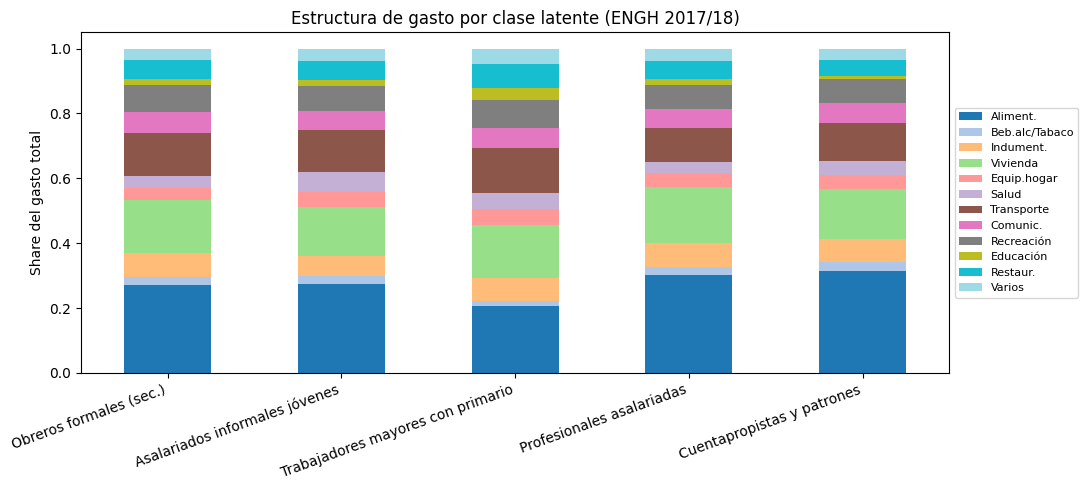

In [22]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = shares_by_class.copy()
plot_df.index = [CLASS_NAMES[i] for i in plot_df.index]
plot_df.columns = ["Aliment.","Beb.alc/Tabaco","Indument.","Vivienda","Equip.hogar",
                   "Salud","Transporte","Comunic.","Recreación","Educación",
                   "Restaur.","Varios"]
plot_df.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_title("Estructura de gasto por clase latente (ENGH 2017/18)")
ax.set_ylabel("Share del gasto total"); ax.set_xlabel("")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
fig.savefig("figures/02_shares_by_class.png", dpi=120)
plt.show()

## IPC por división — INDEC real

Cargamos la serie mensual del INDEC con apertura por las 12 divisiones COICOP, base diciembre 2016 = 100. Pasos:

1. **Renombrar columnas** del CSV INDEC al formato `div_01..div_12` que usa el resto del POC. El orden del CSV coincide 1:1 con el orden COICOP de la ENGH.
2. **Filtrar a 2017-01-01 en adelante**, agregar a trimestres por promedio.
3. **Rebasear a 2017Q1 = 100** para que la base coincida con el resto del POC.
4. **Sanity check**: reconstruir el IPC oficial usando los `share` promedio de la ENGH y compararlo con la columna `nivel_general`. Si la diferencia es chica (<1%), valida que las shares de la ENGH están bien calculadas y que las divisiones se mapean correctamente.

In [4]:
ipc_raw = pd.read_csv("data/ipc_indec_real.csv", parse_dates=["indice_tiempo"])

col_map = {
    "ipc_2016_alimentos_bebidas": "div_01",
    "ipc_2016_bebidas_alcoholicas": "div_02",
    "ipc_2016_indumentaria": "div_03",
    "ipc_2016_vivienda": "div_04",
    "ipc_2016_equipamiento_del_hogar": "div_05",
    "ipc_2016_atencion_medica_salud": "div_06",
    "ipc_2016_transporte": "div_07",
    "ipc_2016_informacion_comunicacion": "div_08",
    "ipc_2016_recreacion_cultura": "div_09",
    "ipc_2016_educacion": "div_10",
    "ipc_2016_restauranes_hoteles": "div_11",
    "ipc_2016_bienes_servicios_varios": "div_12",
}
ipc_m = ipc_raw[["indice_tiempo"] + list(col_map.keys())].rename(columns=col_map)
ipc_m["nivel_general"] = ipc_raw["ipc_2016_nivel_general"]
ipc_m = ipc_m[ipc_m["indice_tiempo"] >= "2017-01-01"].copy()
ipc_m["trimestre"] = ipc_m["indice_tiempo"].dt.to_period("Q").astype(str)

ipc = (ipc_m.groupby("trimestre")[list(col_map.values()) + ["nivel_general"]]
            .mean().sort_index())

# Rebasear a 2017Q1 = 100
base = ipc.iloc[0].copy()
for c in ipc.columns:
    ipc[c] = ipc[c] / base[c] * 100
ipc.to_csv("data/ipc_real_quarterly.csv")
print(f"IPC INDEC trimestral, base 2017Q1=100. {len(ipc)} trimestres ({ipc.index[0]} → {ipc.index[-1]})")
print(ipc.iloc[[0, 8, 16, 24, -1]].round(0))

# Sanity check: el IPC oficial reconstruido a partir de las shares debería pegar bien
overall_shares = np.array([
    (hog_lab[f"share_{i:02d}"]*hog_lab["pondera"]).sum() / hog_lab["pondera"].sum()
    for i in range(1,13)
])
ipc_reconstr = ipc[[f"div_{i:02d}" for i in range(1,13)]].values @ overall_shares
diff_pct = (ipc_reconstr[-1] / ipc["nivel_general"].iloc[-1] - 1) * 100
print(f"\nSanity check: IPC oficial reconstruido vs publicado, último trim: {diff_pct:+.2f}%")
print("Si esta diferencia es chica (<1-2%), las shares y el mapeo de divisiones están OK.")

IPC INDEC trimestral, base 2017Q1=100. 37 trimestres (2017Q1 → 2026Q1)
            div_01  div_02  div_03  div_04  div_05   div_06   div_07  div_08  \
trimestre                                                                      
2017Q1       100.0   100.0   100.0   100.0   100.0    100.0    100.0   100.0   
2019Q1       193.0   162.0   162.0   221.0   184.0    193.0    203.0   213.0   
2021Q1       415.0   332.0   415.0   340.0   422.0    409.0    399.0   400.0   
2023Q1      1337.0  1032.0  1553.0   908.0  1271.0   1235.0   1163.0   879.0   
2026Q1     11298.0  7422.0  8226.0  9999.0  8648.0  10839.0  10369.0  9450.0   

           div_09  div_10   div_11   div_12  nivel_general  
trimestre                                                   
2017Q1      100.0   100.0    100.0    100.0          100.0  
2019Q1      176.0   178.0    174.0    187.0          190.0  
2021Q1      402.0   337.0    362.0    367.0          391.0  
2023Q1     1170.0  1057.0   1315.0   1101.0         1220.0  
20

## D-CPI por clase

Para cada clase, el D-CPI es Σ_d (share_d × IPC_d). Como sanity, también calculamos el "IPC oficial reconstruido" (con shares promedio del país) y lo comparamos con el `nivel_general` publicado por el INDEC.

In [5]:
ipc_cols = [f"div_{i:02d}" for i in range(1,13)]
M = ipc[ipc_cols].values   # n_t x 12

dcpi = pd.DataFrame(index=ipc.index)
for c in shares_by_class.index:
    s = np.array([shares_by_class.loc[c, f"share_{i:02d}"] for i in range(1,13)])
    dcpi[f"class_{c}"] = M @ s
dcpi["IPC_oficial"] = ipc["nivel_general"].values  # publicado, no reconstruido
dcpi.to_csv("data/dcpi_by_class.csv")
print("Inflación acumulada 2017Q1 → último trimestre disponible:")
print(((dcpi.iloc[-1] / 100 - 1) * 100).round(1))

Inflación acumulada 2017Q1 → último trimestre disponible:
class_0        10141.1
class_1        10181.5
class_2        10103.4
class_3        10165.7
class_4        10182.8
IPC_oficial    10207.2
Name: 2026Q1, dtype: float64


## Salarios reales por clase — IPC oficial vs D-CPI propio

In [6]:
eph = pd.read_parquet("data/eph_with_lca.parquet")
eph["trimestre"] = eph["ANO4"].astype(int).astype(str) + "Q" + eph["TRIMESTRE"].astype(int).astype(str)
def wmean_s(g, col, w):
    W = g[w].sum()
    return (g[col]*g[w]).sum() / W
wages = eph.groupby(["trimestre","LCA_class"]).apply(
    lambda g: wmean_s(g, "P21", "PONDERA")).unstack()
wages.columns = [f"class_{c}" for c in wages.columns]
wages = wages.sort_index()

common = wages.index.intersection(dcpi.index)
wages = wages.loc[common]; dcpi_a = dcpi.loc[common]

real_own = pd.DataFrame(index=common)
real_off = pd.DataFrame(index=common)
for c in range(5):
    real_own[f"class_{c}"] = wages[f"class_{c}"] / dcpi_a[f"class_{c}"] * 100
    real_off[f"class_{c}"] = wages[f"class_{c}"] / dcpi_a["IPC_oficial"] * 100

real_own_idx = real_own.div(real_own.iloc[0]) * 100
real_off_idx = real_off.div(real_off.iloc[0]) * 100
real_own_idx.to_csv("data/real_wages_own_dcpi.csv")
real_off_idx.to_csv("data/real_wages_official_ipc.csv")

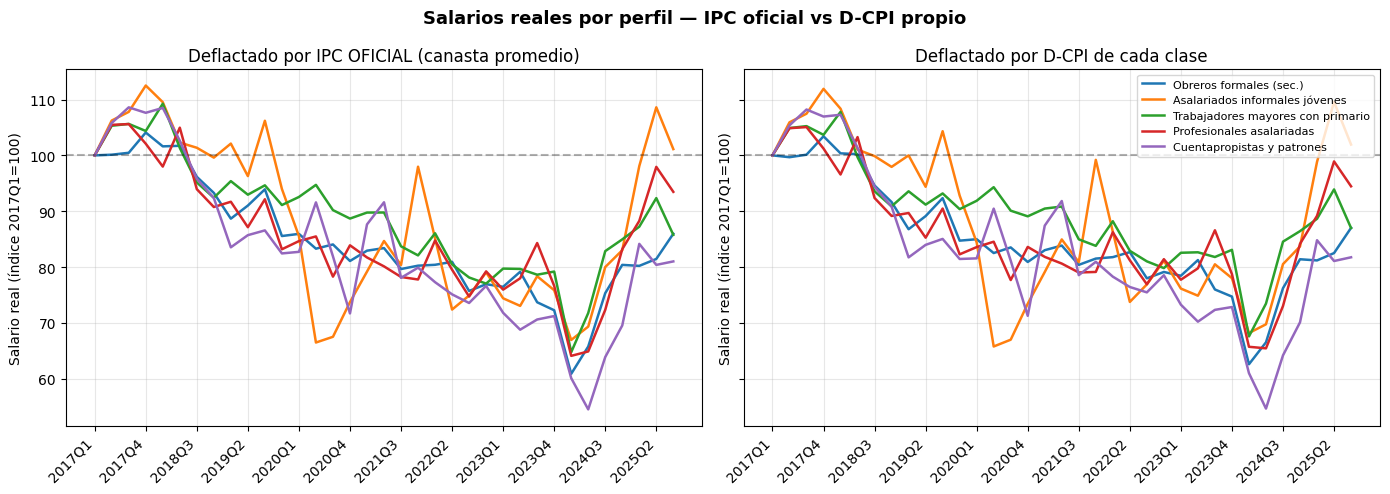

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for c in range(5):
    axes[0].plot(real_off_idx.index, real_off_idx[f"class_{c}"], lw=1.8, label=CLASS_NAMES[c])
    axes[1].plot(real_own_idx.index, real_own_idx[f"class_{c}"], lw=1.8, label=CLASS_NAMES[c])
axes[0].set_title("Deflactado por IPC OFICIAL (canasta promedio)")
axes[1].set_title("Deflactado por D-CPI de cada clase")
for ax in axes:
    ax.axhline(100, ls="--", color="black", alpha=0.3)
    ax.set_ylabel("Salario real (índice 2017Q1=100)")
    ax.grid(alpha=0.3)
    step = max(1, len(real_off_idx)//9)
    ax.set_xticks(real_off_idx.index[::step])
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
axes[1].legend(loc="upper right", fontsize=8)
fig.suptitle("Salarios reales por perfil — IPC oficial vs D-CPI propio",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig("figures/03_real_wages_comparison.png", dpi=120)
plt.show()

## Money chart: ¿quién perdió cuánto?

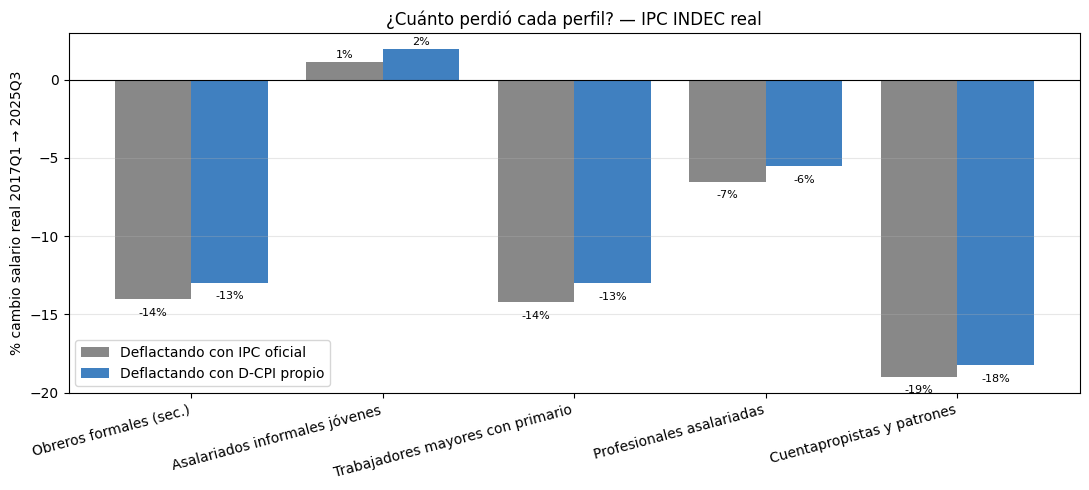


Resumen final — pérdida salario real 2017Q1 → 2025Q3:
                                   IPC_oficial  D-CPI_propio
Obreros formales (sec.)                  -14.0         -13.0
Asalariados informales jóvenes             1.1           1.9
Trabajadores mayores con primario        -14.2         -13.0
Profesionales asalariadas                 -6.5          -5.5
Cuentapropistas y patrones               -19.0         -18.2


In [8]:
loss_off = (real_off_idx.iloc[-1] - 100)
loss_own = (real_own_idx.iloc[-1] - 100)

fig, ax = plt.subplots(figsize=(11, 5))
xpos = np.arange(5); w = 0.4
b1 = ax.bar(xpos - w/2, loss_off.values, w, label="Deflactando con IPC oficial", color="#888")
b2 = ax.bar(xpos + w/2, loss_own.values, w, label="Deflactando con D-CPI propio", color="#4080c0")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(xpos)
ax.set_xticklabels([CLASS_NAMES[i] for i in range(5)], rotation=15, ha="right")
ax.set_ylabel("% cambio salario real 2017Q1 → 2025Q3")
ax.set_title("¿Cuánto perdió cada perfil? — IPC INDEC real")
ax.legend(); ax.grid(alpha=0.3, axis="y")
for bars in [b1, b2]:
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{h:.0f}%", xy=(b.get_x()+b.get_width()/2, h),
                    xytext=(0, 3 if h>=0 else -12), textcoords="offset points",
                    ha="center", fontsize=8)
fig.tight_layout()
fig.savefig("figures/04_money_chart.png", dpi=120)
plt.show()

print("\nResumen final — pérdida salario real 2017Q1 → 2025Q3:")
result = pd.DataFrame({"IPC_oficial": loss_off, "D-CPI_propio": loss_own}).round(1)
result.index = [CLASS_NAMES[i] for i in range(5)]
print(result)

## Limitaciones (declaración honesta)

1. **CIA.** El matching asume independencia condicional y no se testea directamente.
2. **Asimetría rica/pobre.** El LCA usa 6 variables; el matching, 5. La variable `FORMAL` (formalidad) no entra al matching por falta de equivalente directo en ENGH.
3. **Asignación al hogar vía ocupado de mayor ingreso.** Es una simplificación; no siempre coincide con el jefe declarado.
4. **Canasta estática.** La estructura de gasto se asume constante 2017–2025 (la ENGH es una sola foto).
5. **Pesos replicados sin uso.** No se usan los 200 pesos replicados de la ENGH para errores estándar formales. Los D-CPI son puntuales.
6. **Sub-reporte de ingresos.** Cuentapropistas y patrones tienden a sub-declarar ingresos en EPH; los resultados de la clase 4 hay que tomarlos con cautela.

In [20]:
real_own_idx

,class_0,class_1,class_2,class_3,class_4
trimestre,,,,,
2017Q1,100.000000,100.000000,100.000000,100.000000,100.000000
2017Q2,99.672610,105.919064,104.890306,104.868180,105.373417
2017Q3,100.122647,107.460139,105.237059,105.060531,108.207058
2017Q4,103.416288,111.908430,103.676096,101.220831,106.949352
2018Q1,100.364001,108.357065,107.784382,96.580676,107.266276
2018Q2,100.217166,101.031456,99.671526,103.277963,101.359299
2018Q3,94.607448,99.871051,93.577434,92.372624,94.383577
2018Q4,91.650086,97.943785,90.885882,89.162254,90.817739
2019Q1,86.781644,99.995963,93.570728,89.685529,81.744125
